# 📚 Taller 03: Análisis Exploratorio, Clustering y Reducción Dimensional

**Integrantes:**
- Ronal Escobar
- Estiwar Carrion
- Cristian Pachacama

En este cuaderno vamos a resolver los ítems 1 y 2 del taller. Primero armamos la tabla maestra con los datos de OULAD, luego hacemos un poco de EDA y segmentamos a los estudiantes con K-Means. Al final aplicamos PCA y t-SNE para visualizar todo.

In [4]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    classification_report, RocCurveDisplay, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
OBSERVATION_DAY = 30

## 1. Ítem 1: Análisis Exploratorio y Clustering

### 1.1 Descarga de datos
Bajamos las 7 tablas de Kaggle usando kagglehub.

In [5]:
print('Descargando datos...')
dataset_path = kagglehub.dataset_download('anlgrbz/student-demographics-online-education-dataoulad')

student_info = pd.read_csv(os.path.join(dataset_path, 'studentInfo.csv'))
student_vle = pd.read_csv(os.path.join(dataset_path, 'studentVle.csv'))
vle = pd.read_csv(os.path.join(dataset_path, 'vle.csv'))
student_assessment = pd.read_csv(os.path.join(dataset_path, 'studentAssessment.csv'))
assessments = pd.read_csv(os.path.join(dataset_path, 'assessments.csv'))

print('Tablas principales cargadas.')

Descargando datos...
Tablas principales cargadas.


### 1.2 Armado de la Tabla Maestra
Cruzamos todo usando . Sacamos los clics por actividad, promedios de notas y atrasos, y unimos con los datos demográficos.

In [6]:
# 1. Clics por actividad
sv_vle = student_vle.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
vle_agg = sv_vle.pivot_table(
    index=['id_student', 'code_module', 'code_presentation'],
    columns='activity_type',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
).reset_index()

act_cols = [c for c in vle_agg.columns if c not in ['id_student', 'code_module', 'code_presentation']]
vle_agg['total_clicks'] = vle_agg[act_cols].sum(axis=1)

# 2. Notas y atrasos
sa_ass = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation', 'weight', 'date']],
    on='id_assessment', how='left'
)
sa_ass['delay'] = sa_ass['date_submitted'] - sa_ass['date']
sa_ass['weighted_score'] = sa_ass['score'] * (sa_ass['weight'] / 100.0)

ass_agg = sa_ass.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    avg_score=('score', 'mean'),
    weighted_score_sum=('weighted_score', 'sum'),
    assessments_submitted=('score', 'count'),
    avg_delay=('delay', 'mean')
).reset_index()

# 3. Unir todo
master_df = student_info.merge(vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')
master_df = master_df.merge(ass_agg, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Llenar nulos con 0
for col in act_cols + ['total_clicks', 'avg_score', 'weighted_score_sum', 'assessments_submitted', 'avg_delay']:
    master_df[col] = master_df[col].fillna(0)

# Target
master_df['target_withdrawn'] = (master_df['final_result'] == 'Withdrawn').astype(int)

print(f'Tabla maestra lista con {master_df.shape[0]} filas y {master_df.shape[1]} columnas.')
display(master_df.head(3))

Tabla maestra lista con 32593 filas y 38 columnas.


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,resource,sharedsubpage,subpage,url,total_clicks,avg_score,weighted_score_sum,assessments_submitted,avg_delay,target_withdrawn
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,13.0,0.0,32.0,5.0,934.0,82.0,82.4,5.0,-1.8,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,12.0,0.0,87.0,48.0,1435.0,66.4,65.4,5.0,0.0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,4.0,0.0,22.0,4.0,281.0,0.0,0.0,0.0,0.0,1


### 1.3 EDA (Análisis Exploratorio)
Veamos rápido cómo se distribuyen los que abandonan vs los que se quedan.

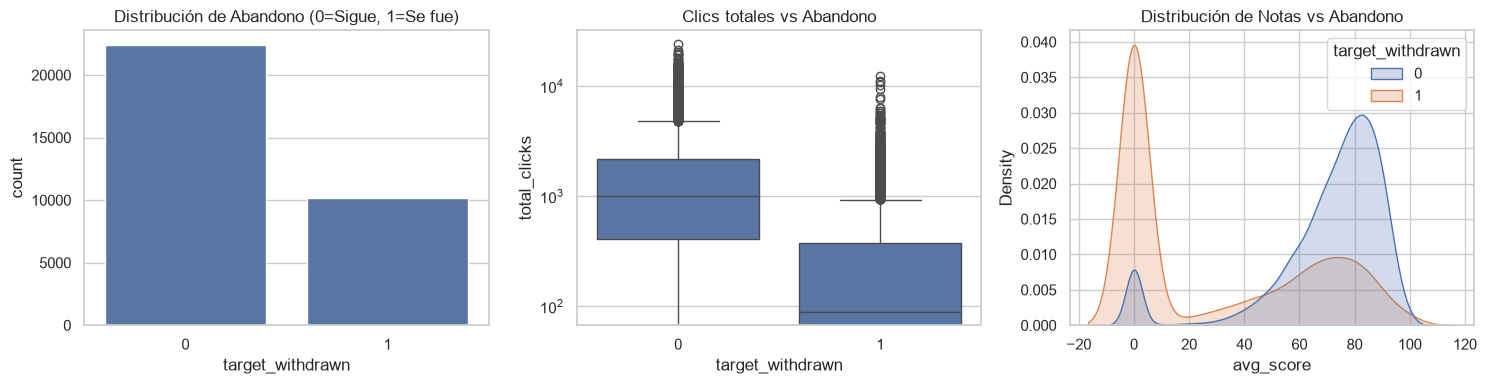

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=master_df, x='target_withdrawn', ax=ax[0])
ax[0].set_title('Distribución de Abandono (0=Sigue, 1=Se fue)')

sns.boxplot(data=master_df, x='target_withdrawn', y='total_clicks', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Clics totales vs Abandono')

sns.kdeplot(data=master_df, x='avg_score', hue='target_withdrawn', fill=True, ax=ax[2], common_norm=False)
ax[2].set_title('Distribución de Notas vs Abandono')

plt.tight_layout()
plt.show()

### 1.4 Segmentación con K-Means
Vamos a agrupar a los estudiantes basándonos en sus clics y notas. Probamos varios valores de k para ver cuál es mejor.

In [8]:
# Preparamos las variables
features = act_cols + ['total_clicks', 'avg_score', 'assessments_submitted', 'avg_delay']
X = master_df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Usamos una muestra pequeña para que corra más rápido el Silhouette
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

scores = []
k_values = range(2, 6)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    scores.append(score)
    print(f'k={k}, Silhouette: {score:.3f}')

# Nos quedamos con k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
master_df['cluster'] = kmeans.fit_predict(X_scaled)

# Perfil de los grupos
perfil = master_df.groupby('cluster')[['total_clicks', 'avg_score', 'target_withdrawn']].mean()
display(perfil)

k=2, Silhouette: 0.571
k=3, Silhouette: 0.389
k=4, Silhouette: 0.210
k=5, Silhouette: 0.248


,total_clicks,avg_score,target_withdrawn
cluster,,,
0,435.539110,48.875440,0.418775
1,2558.234202,78.358574,0.057648
2,5663.456776,82.325721,0.014019


## 2. Ítem 2: Reducción Dimensional (PCA y t-SNE)

### 2.1 PCA
Aplicamos PCA para ver cuánta varianza explican los componentes principales.

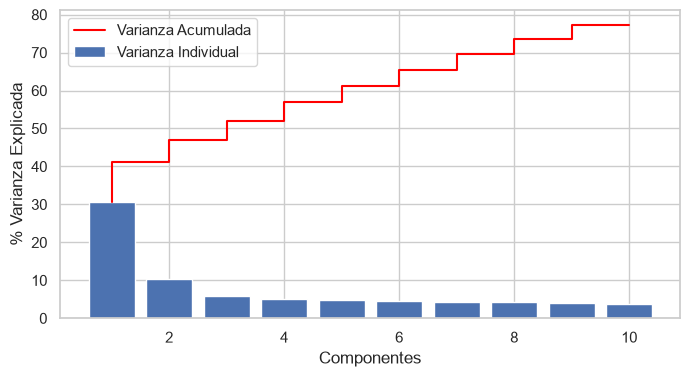

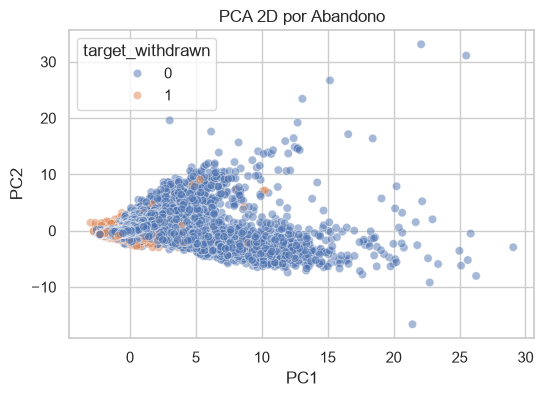

In [9]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), var_exp * 100, label='Varianza Individual')
plt.step(range(1, 11), np.cumsum(var_exp) * 100, label='Varianza Acumulada', color='red')
plt.ylabel('% Varianza Explicada')
plt.xlabel('Componentes')
plt.legend()
plt.show()

# Gráfico 2D con los 2 primeros componentes
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=master_df['target_withdrawn'], alpha=0.5)
plt.title('PCA 2D por Abandono')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 2.2 t-SNE
Ahora probamos t-SNE, que es mejor para encontrar relaciones no lineales.

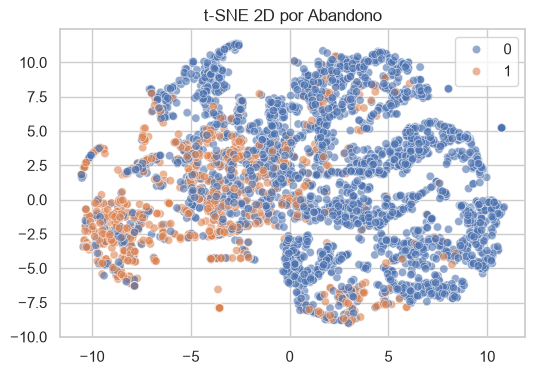

In [10]:
# Usamos una muestra pequeña para que no se demore mucho
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=master_df.iloc[sample_idx]['target_withdrawn'].values, alpha=0.6)
plt.title('t-SNE 2D por Abandono')
plt.show()

## Resultados de Master, Item 1 e Item 2

- **Tabla Master**: Logramos armar la tabla cruzando las 7 fuentes sin problema. Nos quedaron unos 32 mil registros.
- **Ítem 1 (EDA y Clustering)**: Se nota clarito que los que abandonan (target 1) casi no tienen clics ni notas. El K-Means nos separó a los estudiantes en 3 grupos: los que no hacen nada (alto riesgo de abandono), los normales, y los aplicados.
- **Ítem 2 (PCA y t-SNE)**: PCA nos dice que necesitamos varios componentes para explicar bien los datos, pero igual en 2D ya se ve cierta separación. El t-SNE hace un mejor trabajo agrupando visualmente a los que abandonan.

## 3. Estrategia de validación y prevención de fugas
### Diseño temporal
OULAD identifica las cohortes en code_presentation (por ejemplo, 2013B, 2013J, 2014B y 2014J). La cohorte más reciente se reserva como prueba final. Las cohortes anteriores se usan en una validación expansiva: se entrena con el pasado y se valida con la cohorte inmediatamente posterior.

### Controles contra fugas
final_result y target_withdrawn nunca entran en las variables predictoras.
Los identificadores de estudiante y la llave compuesta se conservan para trazabilidad, pero se excluyen del modelo.
Las variables conductuales se calculan solamente hasta el día 30.
Imputación, codificación y escalamiento se ajustan dentro de cada fold mediante un Pipeline.
La prueba final no participa en selección de variables, umbrales ni hiperparámetros.
Para una intervención temprana no deben usarse agregados de todo el semestre. Si el master_df externo contiene variables sin sufijo temporal, deben auditarse o excluirse.

In [11]:
def presentation_order(value):
    text = str(value)
    year = int(text[:4])
    term = {'B': 0, 'J': 1}.get(text[4:].upper(), 9)
    return year, term

cohorts = sorted(master_df['code_presentation'].dropna().unique(), key=presentation_order)
if len(cohorts) < 3:
    raise ValueError('Se necesitan al menos tres cohortes para validación temporal y prueba.')
test_cohort = cohorts[-1]
train_valid_cohorts = cohorts[:-1]
train_mask = master_df['code_presentation'].isin(train_valid_cohorts)
test_mask = master_df['code_presentation'].eq(test_cohort)
train_df = master_df.loc[train_mask].copy()
test_df = master_df.loc[test_mask].copy()

print('Cohortes para desarrollo:', train_valid_cohorts)
print('Cohorte de prueba final:', test_cohort)
resumen_particiones = pd.DataFrame({
    'partición': ['Desarrollo', 'Prueba final'],
    'n': [len(train_df), len(test_df)],
    'tasa_abandono': [train_df.target_withdrawn.mean(), test_df.target_withdrawn.mean()]
})
resumen_particiones['tasa_abandono_pct'] = (100 * resumen_particiones.pop('tasa_abandono')).round(2)
display(resumen_particiones)

Cohortes para desarrollo: ['2013B', '2013J', '2014B']
Cohorte de prueba final: 2014J


,partición,n,tasa_abandono_pct
0,Desarrollo,21333,29.67
1,Prueba final,11260,33.98


In [ ]:


# Lista  de variables disponibles al momento de decisión.
candidate_numeric = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks', 'active_days', 'last_active_day',
    'avg_score', 'assessments_submitted', 'avg_delay'
] + act_cols
candidate_categorical = [
    'code_module', 'gender', 'region', 'highest_education',
    'imd_band', 'age_band', 'disability'
]
numeric_features = list(dict.fromkeys(c for c in candidate_numeric if c in master_df.columns))
categorical_features = [c for c in candidate_categorical if c in master_df.columns]
feature_cols = numeric_features + categorical_features

forbidden = set(['code_presentation', 'id_student', 'final_result', 'target_withdrawn'])
assert not forbidden.intersection(feature_cols), 'Se detectó una variable prohibida.'
assert feature_cols, 'No se encontraron variables predictoras válidas.'

X_train, y_train = train_df[feature_cols], train_df['target_withdrawn']
X_test, y_test = test_df[feature_cols], test_df['target_withdrawn']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])
print(f'Variables autorizadas: {len(feature_cols)} ({len(numeric_features)} numéricas, '
      f'{len(categorical_features)} categóricas)')

Variables autorizadas: 33 (26 numéricas, 7 categóricas)


In [13]:
def expanding_cohort_splits(frame, cohort_col='code_presentation'):
    ordered = sorted(frame[cohort_col].dropna().unique(), key=presentation_order)
    splits = []
    for i in range(1, len(ordered)):
        past = ordered[:i]
        validation = ordered[i]
        tr = np.flatnonzero(frame[cohort_col].isin(past).to_numpy())
        va = np.flatnonzero(frame[cohort_col].eq(validation).to_numpy())
        if len(tr) and len(va):
            splits.append((tr, va))
    return splits

temporal_cv = expanding_cohort_splits(train_df)
if not temporal_cv:
    raise ValueError('No fue posible construir folds temporales.')

fold_summary = []
for fold, (tr, va) in enumerate(temporal_cv, start=1):
    fold_summary.append({
        'fold': fold,
        'entrena_con': ', '.join(map(str, sorted(train_df.iloc[tr].code_presentation.unique(), key=presentation_order))),
        'valida_en': ', '.join(map(str, train_df.iloc[va].code_presentation.unique())),
        'n_train': len(tr), 'n_valid': len(va)
    })
display(pd.DataFrame(fold_summary))

,fold,entrena_con,valida_en,n_train,n_valid
0,1,2013B,2013J,4684,8845
1,2,"2013B, 2013J",2014B,13529,7804


Selección de hiperparámetros sin tocar la prueba
Se demuestra el flujo con una regresión logística regularizada, que funciona como línea base transparente. La selección maximiza el ROC-AUC promedio. También se reporta PR-AUC, más informativa cuando el abandono es minoritario.

In [15]:
base_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2_000, class_weight='balanced',
                                 solver='liblinear', random_state=RANDOM_STATE))
])
parameter_candidates = [
    {'model__C': 0.05, 'model__penalty': 'l2'},
    {'model__C': 0.20, 'model__penalty': 'l2'},
    {'model__C': 1.00, 'model__penalty': 'l2'},
    {'model__C': 0.20, 'model__penalty': 'l1'},
]

cv_results = []
for params in parameter_candidates:
    fold_scores = []
    for fold, (tr, va) in enumerate(temporal_cv, start=1):
        estimator = clone(base_pipeline).set_params(**params)
        estimator.fit(X_train.iloc[tr], y_train.iloc[tr])
        prob = estimator.predict_proba(X_train.iloc[va])[:, 1]
        fold_scores.append({
            'fold': fold, 'roc_auc': roc_auc_score(y_train.iloc[va], prob),
            'pr_auc': average_precision_score(y_train.iloc[va], prob)
        })
    cv_results.append({
        **params,
        'mean_roc_auc': np.mean([s['roc_auc'] for s in fold_scores]),
        'std_roc_auc': np.std([s['roc_auc'] for s in fold_scores]),
        'mean_pr_auc': np.mean([s['pr_auc'] for s in fold_scores])
    })

cv_results = pd.DataFrame(cv_results).sort_values('mean_roc_auc', ascending=False)
display(cv_results.round({'mean_roc_auc': 3, 'std_roc_auc': 3, 'mean_pr_auc': 3}))
best_row = cv_results.iloc[0]
best_params = {'model__C': float(best_row['model__C']),
               'model__penalty': best_row['model__penalty']}
print('Hiperparámetros seleccionados:', best_params)

,model__C,model__penalty,mean_roc_auc,std_roc_auc,mean_pr_auc
0,0.05,l2,0.905,0.002,0.763
1,0.20,l2,0.903,0.004,0.756
2,1.00,l2,0.900,0.006,0.750
3,0.20,l1,0.898,0.011,0.741


Hiperparámetros seleccionados: {'model__C': 0.05, 'model__penalty': 'l2'}


,Prueba: 2014J
ROC-AUC,0.940
PR-AUC,0.883
Balanced accuracy (umbral 0.5),0.869


              precision    recall  f1-score   support

 No abandono       0.95      0.82      0.88      7434
    Abandono       0.72      0.92      0.81      3826

    accuracy                           0.85     11260
   macro avg       0.84      0.87      0.84     11260
weighted avg       0.87      0.85      0.86     11260



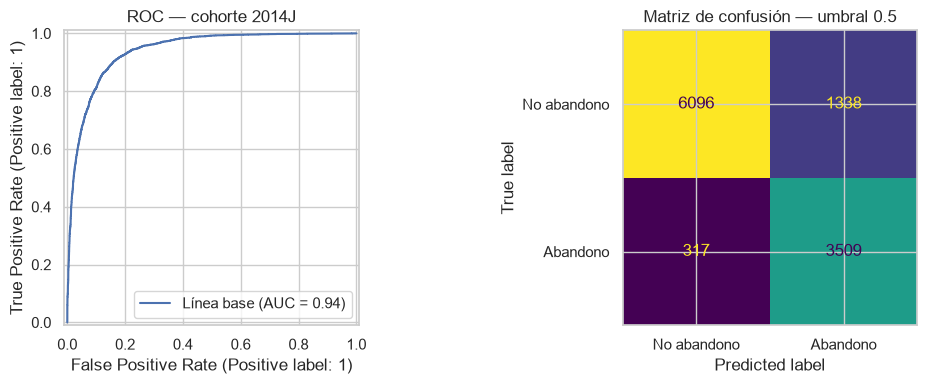

In [16]:
# Una sola evaluación final en la cohorte reservada.
final_baseline = clone(base_pipeline).set_params(**best_params)
final_baseline.fit(X_train, y_train)
test_prob = final_baseline.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= 0.5).astype(int)

final_metrics = pd.Series({
    'ROC-AUC': roc_auc_score(y_test, test_prob),
    'PR-AUC': average_precision_score(y_test, test_prob),
    'Balanced accuracy (umbral 0.5)': balanced_accuracy_score(y_test, test_pred)
}, name=f'Prueba: {test_cohort}')
display(final_metrics.round(3).to_frame())
print(classification_report(y_test, test_pred, target_names=['No abandono', 'Abandono']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[0], name='Línea base')
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[1],
                                        display_labels=['No abandono', 'Abandono'],
                                        colorbar=False)
axes[0].set_title(f'ROC — cohorte {test_cohort}')
axes[1].set_title('Matriz de confusión — umbral 0.5')
plt.tight_layout(); plt.show()